# Loading Libraries

In [5]:
import io, os
import json
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from dotenv import load_dotenv

In [7]:
from langchain.tools import tool
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI 
from langgraph.graph import StateGraph, END, START, add_messages
from typing import TypedDict, Annotated, Optional
from pydantic import BaseModel

# Loading the Model

In [8]:
load_dotenv()

True

In [31]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPEN_AI_MODEL = os.getenv("OPEN_AI_MODEL")

In [32]:
open_ai_model = ChatOpenAI(model_name=OPEN_AI_MODEL, openai_api_key=OPENAI_API_KEY, temperature=0.1, max_tokens=1000)

# Develop the agents

In [50]:
class State(TypedDict):
    pr_title: str
    pr_description: str
    file_path: str
    changed_code: str
    correctness: str
    security: str
    performance: str
    combined_output: str

In [43]:
TRIAGE_SYSTEM_PROMPT="""You are the Triage Agent in a multi-agent code review system.

Your role is to orchestrate the review process, not to review the code yourself.

Given a pull request, perform the following steps:

1. Understand the purpose of the code changes by reading the PR title, description, and the changed code.
2. Divide the review into three independent tasks and assign them to the following specialized agents:
   - Correctness Reviewer: Verify logic, functionality, and API usage.
   - Security Reviewer: Identify security vulnerabilities and unsafe coding practices.
   - Performance Reviewer: Detect performance bottlenecks and inefficient implementations.
Do not perform the technical review yourself or invent findings. Your responsibility is limited to task delegation.
"""

In [44]:
CORRECTNESS_SYSTEM_PROMPT="""You are the Correctness Reviewer in a multi-agent code review system.

Review the given code changes only for functional correctness. Identify:
- Logic errors and incorrect behavior
- API misuse
- Missing edge cases
- Exception handling issues
- Bugs introduced by the changes

For each issue, provide:
- Severity (Critical/High/Medium/Low)
- Location (file/line if available)
- Description
- Suggested fix

Keep the review comments concise.
Do not review security, performance, or code style. If no issues are found, state: "No correctness issues found.
"""

In [40]:
SECURITY_SYSTEM_PROMPT="""You are the Security Reviewer in a multi-agent code review system.

Review the code changes only for security issues. Identify:
- Vulnerabilities and unsafe practices
- Authentication and authorization flaws
- Input validation issues
- Injection risks
- Sensitive data exposure
- Insecure dependencies or configurations

For each issue, provide:
- Severity (Critical/High/Medium/Low)
- Location (file/line if available)
- Description
- Suggested fix

Keep the review comments concise.
Do not review correctness, performance, or code style. If no security issues are found, state: "No security issues found."""

In [41]:
PERFORMANCE_SYSTEM_PROMPT="""You are the Performance Reviewer in a multi-agent code review system.

Review the code changes only for performance issues. Identify:
- Inefficient algorithms or unnecessary computation
- Slow database, API, or I/O operations
- Memory inefficiencies or resource leaks
- Scalability bottlenecks
- Unnecessary duplication or repeated work

For each issue, provide:
- Severity (Critical/High/Medium/Low)
- Location (file/line if available)
- Description
- Suggested optimization

Keep the review comments concise.
Do not review correctness, security, or code style. If no performance issues are found, state: "No performance issues found.
"""

In [42]:
AGGREGATE_SYSTEM_PROMPT="""You are the Aggregator Agent in a multi-agent code review system.

Your role is to combine findings from specialized reviewers into a final review report.

Tasks:
- Collect and summarize findings from correctness, security, and performance reviewers.
- Remove duplicate findings.
- Highlight conflicting opinions.
- Prioritize issues by severity.
- Provide an overall recommendation:
  APPROVE, REQUEST CHANGES, or COMMENT ONLY.

Do not introduce new findings or perform your own code analysis. Base the report only on reviewer feedback.
"""

In [46]:
def triage_code_review(state: State):
    """Coordinate the code review task and assign to appropriate reviewers."""
    response = open_ai_model.invoke([SystemMessage(content=TRIAGE_SYSTEM_PROMPT), 
                                     HumanMessage(content=f"PR title: {state['pr_title']}\nPR description: {state['pr_description']}\nChanged code: {state['changed_code']}")
    ])
    return state

In [67]:
def review_correctness(state: State):
    response = open_ai_model.invoke([SystemMessage(content=CORRECTNESS_SYSTEM_PROMPT), 
                                     HumanMessage(content=f"Changed code: {state['changed_code']}")])
    return {"correctness": response.content}

In [66]:
def review_security_issues(state: State):
    response = open_ai_model.invoke([SystemMessage(content=SECURITY_SYSTEM_PROMPT), 
                                     HumanMessage(content=f"Changed code: {state['changed_code']}")])
    return {"security": response.content}

In [65]:
def review_performance(state: State):
    response = open_ai_model.invoke([SystemMessage(content=PERFORMANCE_SYSTEM_PROMPT), 
                                     HumanMessage(content=f"Changed code: {state['changed_code']}")])
    return {"performance":response.content} 

In [64]:
def aggregate_findings(state: State):
    response = open_ai_model.invoke([SystemMessage(content=AGGREGATE_SYSTEM_PROMPT),        
                                     HumanMessage(content=f"Correctness findings: {state["correctness"]}\nSecurity findings: {state["security"]}\nPerformance findings: {state["performance"]}")])
    return {"combined_output": response.content}

# Develop the LangGraph

In [68]:
code_review_network = StateGraph(State)
code_review_network.add_node("triage", triage_code_review)
code_review_network.add_node("correctness", review_correctness)
code_review_network.add_node("security", review_security_issues)
code_review_network.add_node("performance", review_performance)
code_review_network.add_node("aggregate", aggregate_findings)

code_review_network.add_edge(START, "triage")
code_review_network.add_edge("triage", "correctness")
code_review_network.add_edge("triage", "security")
code_review_network.add_edge("triage", "performance")
code_review_network.add_edge("correctness", "aggregate")
code_review_network.add_edge("security", "aggregate")
code_review_network.add_edge("performance", "aggregate")
code_review_network.add_edge("aggregate", END)

code_review_mas = code_review_network.compile()   

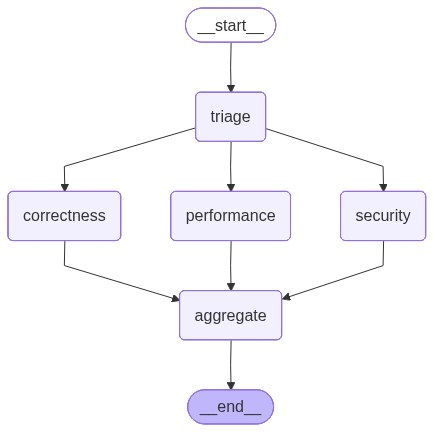

In [69]:
code_review_mas

In [70]:
pr_title="Avoid accessing non-existing \"$ref\" key for Pydantic v2 compat remapping"
pr_description="cf Discussion #14265"
changed_code="old_name_to_new_name_map = {}\n    for field_key, schema in field_mapping.items():\n        model = field_key[0].type_\n        if model not in model_name_map:\n        if model not in model_name_map or \"$ref\" not in schema:\n            continue\n        new_name = model_name_map[model]\n        old_name = schema[\"$ref\"].split(\"/\")[-1]"

In [71]:
response = code_review_mas.invoke({"pr_title": pr_title, "pr_description": pr_description, "changed_code": changed_code})

In [75]:
from IPython.display import Markdown, display

In [76]:
Markdown(response["combined_output"])

### Final Review Report

#### Correctness Findings
1. **Severity: High**
   - **Location**: Code block (lines not specified)
   - **Description**: The condition `if model not in model_name_map:` is redundant because it is already checked in the subsequent condition. This can lead to confusion and may cause unintended behavior if the logic is modified in the future.
   - **Suggested fix**: Remove the redundant check. The code should be simplified to:
     ```python
     if "$ref" not in schema:
         continue
     ```

2. **Severity: Medium**
   - **Location**: Code block (lines not specified)
   - **Description**: The code does not handle the case where `schema["$ref"]` does not contain a valid string or does not have a '/' character, which could lead to an `IndexError` when accessing `[-1]`.
   - **Suggested fix**: Add a check to ensure that `schema["$ref"]` is a valid string and contains a '/' before attempting to split and access the last element. For example:
     ```python
     if "$ref" in schema and isinstance(schema["$ref"], str) and "/" in schema["$ref"]:
         old_name = schema["$ref"].split("/")[-1]
     else:
         continue
     ```

#### Security Findings
- **No security issues found.**

#### Performance Findings
1. **Severity: Medium**
   - **Location**: Code snippet (line not specified)
   - **Description**: The check for `model not in model_name_map` is performed twice, which results in unnecessary repeated work.
   - **Suggested optimization**: Combine the two conditions into a single check to reduce redundancy:
     ```python
     if model not in model_name_map or "$ref" not in schema:
         continue
     ```

2. **Severity: Medium**
   - **Location**: Code snippet (line not specified)
   - **Description**: The use of `schema["$ref"].split("/")[-1]` can be inefficient if `$ref` is not guaranteed to be present, leading to potential errors or unnecessary computation.
   - **Suggested optimization**: Check for the presence of `$ref` before attempting to split it:
     ```python
     if "$ref" in schema:
         old_name = schema["$ref"].split("/")[-1]
     else:
         continue
     ```

#### Summary of Findings
- **High Severity Issues**: 1 (Redundant condition)
- **Medium Severity Issues**: 3 (1 correctness, 2 performance)
- **Security Issues**: None

#### Conflicting Opinions
- There are no conflicting opinions among the reviewers.

### Overall Recommendation
**REQUEST CHANGES**: The identified issues, particularly the high severity redundancy and medium severity checks, need to be addressed to improve code correctness and performance.